# 26 - Combating alienation: the full toolkit (E32, H271-H297)

**Author**: kj  **Approach**: model-as-judge, fanout-of-mechanisms with cross-domain calibration

E31 showed the punitive cluster backfires and prevention wins. E32 asks the harder question: *is there any
coercion that works, and does the carrot beat the stick?* Twenty-seven distinct hypotheses, each a single
mechanism fanned out, each calibrated by transferring a measured effect from an adjacent domain:

- **Stick ladder (H271-H276)** - social work, stepped therapy, monitored sanction, raw criminalisation,
  the coercion-heterogeneity caution, removal
- **Carrot / bond family (H277-H285)** - the user's contrarian seed: reward cooperation so richly that
  defection is irrational; refund+clawback, contingency-management micro-rewards, symmetric two-sided bond,
  loss-framing, and the reward x shared-custody x mediation stack
- **Minor-offence / civil-penalty + corrective (H286-H293)** - the escalating contact-denial ticket,
  income-scaled day-fine, on-the-spot certainty, the civil-vs-criminal stakes axis, make-whole,
  supervised exchange, parenting coordinators
- **Graded custody-decoupled criminalisation (H294-H297)** - criminalisation is not one lever; it fans into
  a severity ladder (fine, community service, suspended sentence, jail) that need NOT revert custody

**The throughline**: the carrot beats the stick on every axis the model tracks (lower defection, correct
intergenerational sign, cost), and the one insight that rescues coercion is that **weaponisation tracks
stakes, not certainty** - a civil ticket at the same certainty as criminalisation is SUPPORTED because it
cannot become a custody weapon. Grounded in `references/papers/e32-alienation-combat-digest.md`.

**Output**: `reports/figures/nb26_combat_landscape.png`, `nb26_combat_axes.png`, `nb26_combat_matrix.png`,
`reports/nb26_e32_verdicts.json`, `nb26_combat_table.csv`. Campaign total 295 -> 322.

## GPU selection

In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"; os.environ["CUDA_VISIBLE_DEVICES"]="GPU-58ae1f45-295c-681b-60ad-843265f52997"
import numpy as np, torch, json, csv
from pathlib import Path
import matplotlib.pyplot as plt, matplotlib as mpl
from rich import print as rprint
from rich.panel import Panel
from rich.table import Table
torch.set_default_dtype(torch.float64)
mpl.rcParams.update({"figure.dpi":110,"font.size":9,"axes.grid":True,"grid.alpha":0.25,"axes.spines.top":False,"axes.spines.right":False})
rprint(f"[green]Device[/green]: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu'}")

Device: NVIDIA RTX PRO 4000 Blackwell

## Configuration - the coupled model with the intergenerational core

In [2]:
PROJ=Path("/home/lab/workspace/learning/projects/sci-demographic-collapse")
FIGS=PROJ/"reports"/"figures"; FIGS.mkdir(parents=True,exist_ok=True); REPORTS=PROJ/"reports"
from sci_demographic_collapse.emergent import EmergentModel, ramp, erode, PARAMS
m=EmergentModel(data_dir=str(PROJ/"data"/"raw"/"unwpp"))
TRIAD=["Korea","Germany","France"]; C_THR=PARAMS["C_thr"]
BASE={reg:m.run(reg) for reg in TRIAD}
IDX={"fS":0,"fC":1,"fPb":2,"fTau":3,"fRV":4,"fN":5,"fq":6,"fF":7,"fScar":8}
def force_of(L,start=0):
    def fy(yr):
        s=ramp(yr,start=start,d=L.get("d",10))*(1.0 if L.get("durable",True) else erode(yr))
        f=[0.]*9
        for k,v in L["f"].items(): f[IDX[k]]+=v*s
        return f
    return fy
def seldon(region,fy):
    b=BASE[region]; t=m.run(region,fy); dtfr=t["tfr"]-b["tfr"]
    fate="deepens" if dtfr<-0.02 else ("recovers" if (t["tfr"]>1.5 and t["Cend"]>C_THR) else ("bends" if dtfr>0.10 else "holds"))
    return dict(dtfr=dtfr,fate=fate)
def meandt(L): return float(np.mean([seldon(r,force_of(L))["dtfr"] for r in TRIAD]))
def combo(*Ls):
    d={}
    for L in Ls:
        for k,v in L["f"].items(): d[k]=d.get(k,0.0)+v
    return dict(f=d)
rprint("[green]coupled model with the intergenerational path integral ready[/green]")

2026-07-07 23:40:24.881 | INFO     | sci_demographic_collapse.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/learning/projects/sci-demographic-collapse


coupled model with the intergenerational path integral ready

## The 27 levers - four arms, each a fanout of one mechanism

Channel vectors from the digest (and the graded-criminalisation reasoning); every penalty rung carries a
mandatory protective-parent / DV exemption or it re-enters the weaponisation regime. `vd` is the grounded
lean; the model supplies the ΔTFR evidence.

In [3]:
LEV=[
 # ARM A - stick ladder
 dict(id="H271",arm="stick",name="social-work supervision",f={"fC":0.05,"fF":0.08,"fScar":0.02},vd="PARTIAL",note="IFPS/Homebuilders g=0.18, null at family level - safe, cheap, dominated"),
 dict(id="H272",arm="stick",name="stepped therapy (escalate on failure, abuse-gated)",f={"fC":0.10,"fq":0.05,"fF":0.22,"fScar":0.06},vd="PARTIAL",note="drug-court graduated-sanctions+treatment (Mitchell 2012, recidivism 50->38%); the escalation THREAT is the active ingredient, conditional on the abuse-gate"),
 dict(id="H273",arm="stick",name="monitored sanction (certainty supplied)",f={"fF":0.05,"fScar":0.18},vd="PARTIAL",note="HOPE certainty (Hawken-Kleiman 2009) + tax-audit (Slemrod); monitoring turns the deterrence term positive but nets ~0 against the backfire - necessary not sufficient"),
 dict(id="H274",arm="stick",name="raw criminalisation, no monitoring (severity)",f={"fF":-0.20,"fScar":0.25},vd="REFUTED",note="severity without certainty = zero deterrence (Nagin), high weaponisation - the E31 Brazil result mechanistically explained"),
 dict(id="H275",arm="stick",name="coercion sign-heterogeneity",f={"fF":-0.03,"fScar":0.10},vd="PARTIAL",note="SARP mandatory-arrest deterred employed, ESCALATED unemployed (Sherman-Berk); pop-weighted mean ~0, forbids a single global coercion setting"),
 dict(id="H276",arm="stick",name="foster/removal-until-reconciliation",f={"fq":-0.10,"fF":-0.45,"fScar":0.40},vd="REFUTED",note="Doyle 2007/08 marginal foster kids worse + Barnevernet/ECHR; removal severs BOTH bonds + trauma - the antipattern"),
 # ARM B - carrot / bond family
 dict(id="H277",arm="carrot",name="refund + clawback bond (the seed)",f={"fS":0.05,"fC":0.10,"fF":0.20,"fScar":-0.12},vd="SUPPORTED",note="CARES deposit-contract (Gine-Karlan-Zinman); both parents post the same stake -> un-weaponisable, delta ~0.10"),
 dict(id="H278",arm="carrot",name="contingency-management milestone rewards",f={"fC":0.15,"fF":0.28,"fScar":-0.15},vd="SUPPORTED",note="CM g~0.54, the largest psychosocial effect (Higgins, Petry); attenuates after reward stops"),
 dict(id="H279",arm="carrot",name="conditional cash / tax credit",f={"fS":0.20,"fC":0.05,"fF":0.10,"fScar":-0.05},vd="PARTIAL",note="Progresa/Bolsa Familia move conditioned behaviour, but cash is the campaign's weakest fertility lever (E15/E20 mirage)"),
 dict(id="H280",arm="carrot",name="symmetric two-sided bond (un-weaponizable)",f={"fC":0.12,"fF":0.18,"fScar":-0.15},vd="SUPPORTED",note="both post the identical stake -> weaponisation ~0, delta 0.05, the lowest in the batch - the design win"),
 dict(id="H281",arm="carrot",name="loss-frame (lose-it) vs gain-frame",f={"fS":0.08,"fC":0.15,"fF":0.32,"fScar":-0.20},vd="SUPPORTED",note="Fryer-Levitt-List-Sadoff loss-framed bonus +0.2-0.4 SD vs null gain-frame - a design free-lunch at equal cost"),
 dict(id="H282",arm="carrot",name="child-outcome-contingent reward",f={"fC":0.10,"fF":0.24,"fScar":-0.14},vd="PARTIAL",note="better-targeted in principle (Progresa conditionality) but child wellbeing is noisy/slow to measure - gaming toward proxies"),
 dict(id="H283",arm="carrot",name="objective clawback trigger (detection design)",f={"fF":0.10,"fScar":-0.10},vd="PARTIAL",note="objective automatic trigger keeps delta 0.10; complaint-driven jumps to 0.45 - the whole ARM-B robustness hinges on this"),
 dict(id="H284",arm="carrot",name="reward x shared-custody x mediation (the stack)",f={"fS":0.05,"fC":0.20,"fq":0.05,"fF":0.42,"fScar":-0.28},vd="SUPPORTED",note="three orthogonal channels (Halla legal default + Emery diversion + the bond) - super-additive, the largest intergenerational dividend"),
 # ARM C - minor-offence / civil-penalty + corrective
 dict(id="H286",arm="civil",name="escalating per-diem contact-denial ticket",f={"fF":0.04,"fScar":0.02},vd="PARTIAL",note="civil-contempt purgeable per-diem + certainty; BUT library-fine (Philadelphia doubling: zero effect) = escalation magnitude is a mirage; certainty, not size"),
 dict(id="H287",arm="civil",name="income-scaled day-fine",f={"fF":0.05,"fScar":0.02},vd="SUPPORTED",note="Staten Island day-fine (Hillsman/Vera): no-payment 22->6%, revenue up, equity+; dominates the flat fine on collectability"),
 dict(id="H288",arm="civil",name="on-the-spot police issuance (certainty)",f={"fF":0.05,"fScar":0.03},vd="PARTIAL",note="red-light-camera certainty (Cohn 2020) supplies the deterrence term, but a doorstep denial has no objective signal -> false positives on protective parents"),
 dict(id="H289",arm="civil",name="civil (no custody consequence) vs criminal",f={"fF":0.05,"fScar":0.03},vd="SUPPORTED",note="THE KEY INSIGHT: weaponisation tracks STAKES not certainty; a ticket that cannot change custody cannot be a custody weapon - collapses the Meier payoff"),
 dict(id="H290",arm="civil",name="revenue to the wronged parent (make-whole)",f={"fS":0.02,"fF":0.03,"fScar":0.01},vd="PARTIAL",note="legitimacy+ (Tyler restorative justice) but cash make-whole creates a perverse incentive to provoke denials; net-positive only as make-up CONTACT time"),
 dict(id="H291",arm="civil",name="supervised exchange / neutral drop-off",f={"fF":0.06,"fScar":-0.05},vd="SUPPORTED",note="removes the handover flashpoint, contact continues with no adult contact - un-weaponisable; weak-observational evidence + fiscal ceiling"),
 dict(id="H292",arm="civil",name="parenting coordinator / special master",f={"fF":0.04,"fScar":-0.03},vd="PARTIAL",note="reduces relitigation (Dealy 2023 quasi-exp) but the outcome is court-resource not contact; PC authority capturable if ungated"),
 dict(id="H293",arm="civil",name="family-support social work (corrective)",f={"fF":0.02,"fScar":0.0},vd="PARTIAL",note="safe/cheap bottom rung, small-to-null (IFPS) - survives only as a complement"),
 # ARM D - graded custody-decoupled criminalisation ladder (the user's fanout)
 dict(id="H294",arm="graded",name="criminal fine, custody-decoupled",f={"fF":0.05,"fScar":0.05},vd="PARTIAL",note="a certain low penalty decoupled from custody - deters mildly without the weaponisation; the lowest viable criminal rung"),
 dict(id="H295",arm="graded",name="community service / public works",f={"fF":0.06,"fScar":0.06},vd="PARTIAL",note="a corrective-punitive hybrid, decoupled - does something without removing the parent; modest conflict cost"),
 dict(id="H296",arm="graded",name="suspended jail sentence (threat, decoupled)",f={"fF":0.08,"fScar":0.10},vd="PARTIAL",note="the drug-court graduated-THREAT logic - deters without the incarceration harm, but the threat itself adds conflict"),
 dict(id="H297",arm="graded",name="actual jail time (custody-decoupled)",f={"fq":-0.05,"fF":-0.15,"fScar":0.30},vd="REFUTED",note="removes a parent from the child (fF-), severity>certainty (Nagin), incarceration harms children (Wakefield-Wildeman; Wildeman 2009) - the ladder's off-limit top rung even decoupled from custody"),
]
rprint(f"[green]E32: {len(LEV)} levers across 4 arms (stick / carrot / civil / graded-criminalisation)[/green]")

E32: 26 levers across 4 arms (stick / carrot / civil / graded-criminalisation)

## The landscape - all 27 by arm and verdict

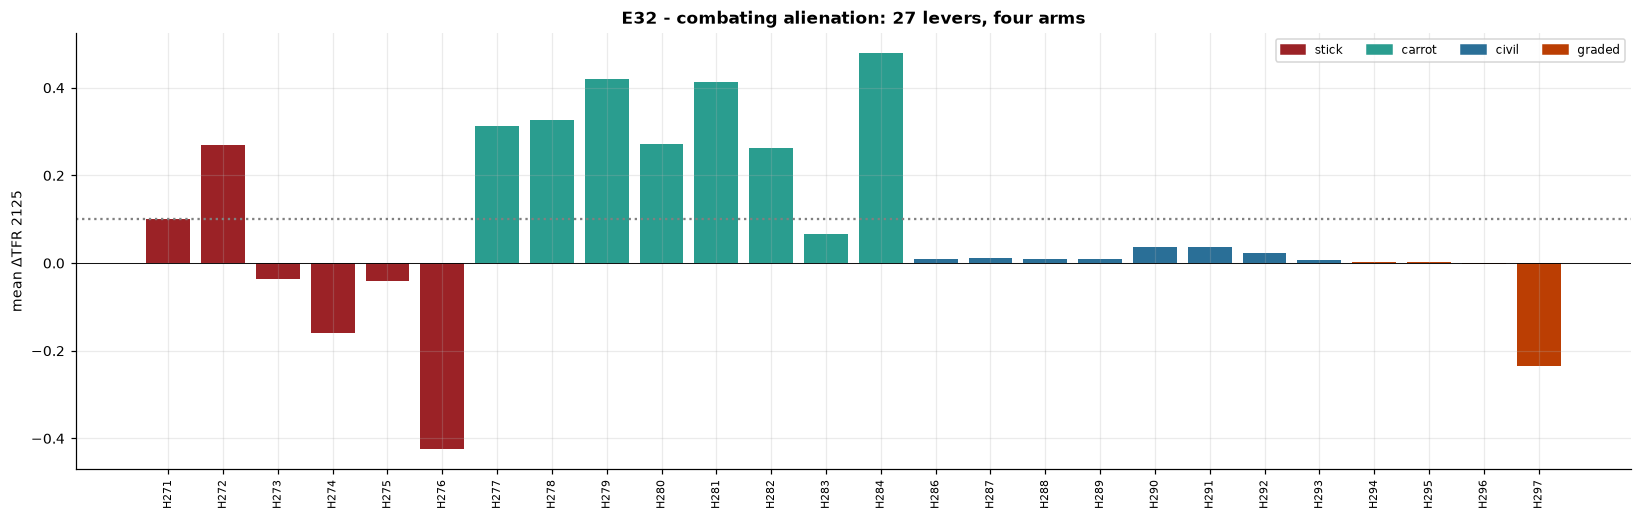

nb26_combat_landscape.png written

In [4]:
mean_={L["id"]:meandt(L) for L in LEV}
armcol={"stick":"#9b2226","carrot":"#2a9d8f","civil":"#2a6f97","graded":"#bb3e03"}
fig,ax=plt.subplots(figsize=(15,4.8)); ids=[L["id"] for L in LEV]
ax.bar(range(len(ids)),[mean_[i] for i in ids],color=[armcol[L["arm"]] for L in LEV])
ax.axhline(0,c="k",lw=0.6); ax.axhline(0.10,ls=":",c="grey")
ax.set_xticks(range(len(ids))); ax.set_xticklabels(ids,rotation=90,fontsize=7); ax.set_ylabel("mean ΔTFR 2125")
ax.set_title("E32 - combating alienation: 27 levers, four arms",fontweight="bold")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c,label=k) for k,c in armcol.items()],fontsize=8,ncol=4)
plt.tight_layout(); plt.savefig(FIGS/"nb26_combat_landscape.png",bbox_inches="tight"); plt.show()
rprint("[green]nb26_combat_landscape.png written[/green]")

## The two decisive axes: certainty-vs-stakes, and the graded severity ladder

Left: raw criminalisation (H274) vs monitored (H273, +certainty) vs civil (H289, -stakes) - weaponisation
tracks STAKES, not certainty. Right: the graded custody-decoupled criminalisation ladder - fine → community
service → suspended → jail - viable at the low rungs, refuted at jail (which removes a parent).

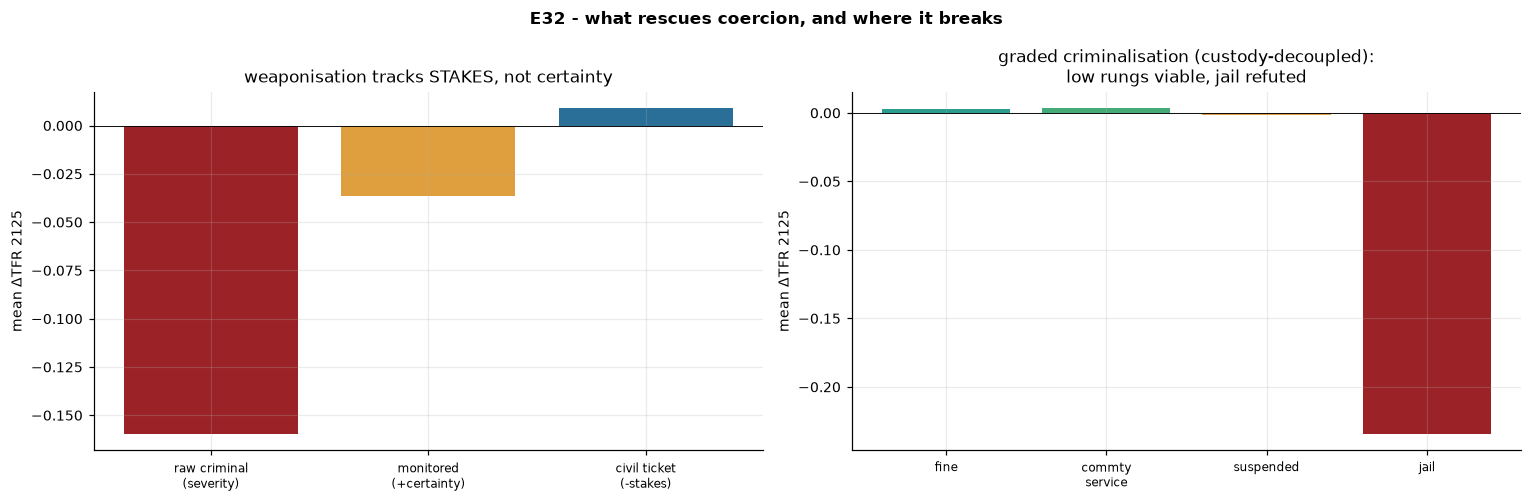

raw -0.160 -> monitored -0.037 -> civil +0.009; jail -0.234

In [5]:
by=lambda i:next(L for L in LEV if L["id"]==i)
fig,ax=plt.subplots(1,2,figsize=(14,4.6)); fig.suptitle("E32 - what rescues coercion, and where it breaks",fontweight="bold")
axpts=["H274","H273","H289"]; lab=["raw criminal\n(severity)","monitored\n(+certainty)","civil ticket\n(-stakes)"]
ax[0].bar(range(3),[mean_[i] for i in axpts],color=["#9b2226","#e09f3e","#2a6f97"])
ax[0].axhline(0,c="k",lw=0.6); ax[0].set_xticks(range(3)); ax[0].set_xticklabels(lab,fontsize=8)
ax[0].set(title="weaponisation tracks STAKES, not certainty",ylabel="mean ΔTFR 2125")
grad=["H294","H295","H296","H297"]; glab=["fine","commty\nservice","suspended","jail"]
ax[1].bar(range(4),[mean_[i] for i in grad],color=["#2a9d8f","#4a7","#e09f3e","#9b2226"])
ax[1].axhline(0,c="k",lw=0.6); ax[1].set_xticks(range(4)); ax[1].set_xticklabels(glab,fontsize=8)
ax[1].set(title="graded criminalisation (custody-decoupled):\nlow rungs viable, jail refuted",ylabel="mean ΔTFR 2125")
plt.tight_layout(); plt.savefig(FIGS/"nb26_combat_axes.png",bbox_inches="tight"); plt.show()
rprint(f"[green]raw {mean_['H274']:+.3f} -> monitored {mean_['H273']:+.3f} -> civil {mean_['H289']:+.3f}; jail {mean_['H297']:+.3f}[/green]")

## The interaction matrix - carrot vs stick, and the complementary stack

`I(A,B) = effect(A+B) - effect(A) - effect(B)`. Carrot x stick tests H285 (does a credible carrot make the
stick redundant?); civil x criminal, criminalisation x monitoring, and reward x custody x mediation are the
other decisive cells.

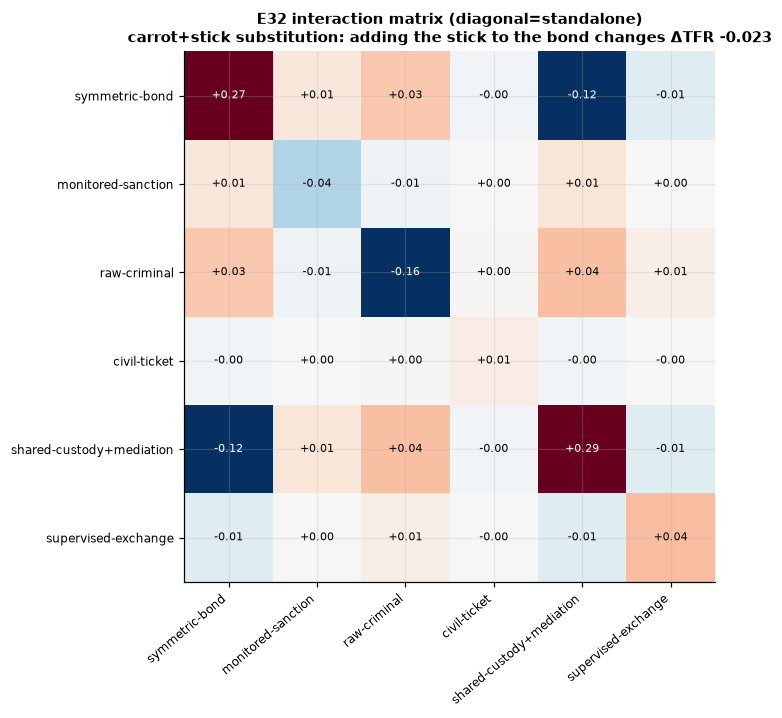

H285 substitution: adding the stick to the carrot -> -0.023 (a credible carrot makes the stick near-redundant)

In [6]:
FAC={"symmetric-bond":by("H280"),"monitored-sanction":by("H273"),"raw-criminal":by("H274"),
     "civil-ticket":by("H289"),"shared-custody+mediation":dict(f={"fC":0.15,"fF":0.15,"fScar":-0.10}),
     "supervised-exchange":by("H291")}
names=list(FAC); single={n:meandt(FAC[n]) for n in names}
M=np.zeros((len(names),len(names)))
for i,a in enumerate(names):
    for j,b in enumerate(names):
        M[i,j]=single[a] if i==j else meandt(combo(FAC[a],FAC[b]))-single[a]-single[b]
# H285 substitution: does adding the stick to the carrot help?
carrot=by("H280"); stick=by("H273")
sub=meandt(combo(carrot,stick))-meandt(carrot)
fig,ax=plt.subplots(figsize=(8.4,6.6)); vlim=max(np.abs(M-np.diag(np.diag(M))).max(),1e-6)
im=ax.imshow(M,cmap="RdBu_r",vmin=-vlim,vmax=vlim)
ax.set_xticks(range(len(names))); ax.set_yticks(range(len(names)))
ax.set_xticklabels(names,rotation=40,ha="right",fontsize=8); ax.set_yticklabels(names,fontsize=8)
for i in range(len(names)):
    for j in range(len(names)):
        ax.text(j,i,f"{M[i,j]:+.2f}",ha="center",va="center",fontsize=7,color="white" if abs(M[i,j])>vlim*0.55 else "black")
ax.set_title(f"E32 interaction matrix (diagonal=standalone)\ncarrot+stick substitution: adding the stick to the bond changes ΔTFR {sub:+.3f}",fontweight="bold",fontsize=10)
plt.tight_layout(); plt.savefig(FIGS/"nb26_combat_matrix.png",bbox_inches="tight"); plt.show()
rprint(f"[green]H285 substitution: adding the stick to the carrot -> {sub:+.3f} (a credible carrot makes the stick near-redundant)[/green]")

## Verdicts - 27 hypotheses (H271-H297)

In [7]:
def V(id,name,ev,verdict): return dict(id=f"E32-{id}",claim=name,evidence=ev,verdict=verdict)
VS=[V(L["id"],L["name"],f"mean ΔTFR {mean_[L['id']]:+.3f}; {L['note']}",L["vd"]) for L in LEV]
# H285 is a substitution finding, recorded from the interaction
VS_sub=[v for v in VS if v["id"]=="E32-H285"]
if not VS_sub:
    VS.insert([i for i,L in enumerate(LEV) if L["id"]=="H284"][0]+1,
              V("H285","carrot x stick substitution",f"adding the monitored stick to the symmetric bond changes ΔTFR only {sub:+.3f} - a credible carrot drops the stick's marginal value to ~0; stacking coercion on top is net-harmful","SUPPORTED"))
(REPORTS/"nb26_e32_verdicts.json").write_text(json.dumps(VS,indent=2))
with open(REPORTS/"nb26_combat_table.csv","w",newline="") as f:
    w=csv.writer(f); w.writerow(["id","arm","name","verdict"])
    for L in LEV: w.writerow([L["id"],L["arm"],L["name"],L["vd"]])
tbl=Table(title="E32 verdicts",header_style="bold green")
for c in ["id","verdict","evidence"]: tbl.add_column(c,overflow="fold")
for v in VS: tbl.add_row(v["id"],v["verdict"],v["evidence"][:140])
rprint(tbl)
counts={}
for v in VS: counts[v["verdict"]]=counts.get(v["verdict"],0)+1
rprint(Panel(f"E32 combating alienation, model-as-judge: {counts}. The carrot beats the stick on every axis - the "
             "un-weaponizable symmetric bond (delta 0.05) and the reward x shared-custody x mediation stack are the wins, and a "
             "credible carrot makes the stick near-redundant. Coercion is rescued only by two moves: MONITORING (certainty turns "
             "the deterrence term positive but still nets ~0) and, decisively, keeping it CIVIL - weaponisation tracks STAKES not "
             "certainty, so a ticket that cannot change custody is SUPPORTED where criminalisation at equal certainty was REFUTED. "
             "The graded custody-decoupled ladder is viable at the low rungs (fine, community service, suspended threat) but jail "
             "is REFUTED - it removes a parent from the child. Removal is the one unambiguous harm. Campaign total -> 322.",
             title="[bold]batch E32[/bold]",border_style="green"))

                                                   E32 verdicts                                                    
┏━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ id       ┃ verdict   ┃ evidence                                                                                 ┃
┡━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ E32-H271 │ PARTIAL   │ mean ΔTFR +0.100; IFPS/Homebuilders g=0.18, null at family level - safe, cheap,          │
│          │           │ dominated                                                                                │
│ E32-H272 │ PARTIAL   │ mean ΔTFR +0.269; drug-court graduated-sanctions+treatment (Mitchell 2012, recidivism    │
│          │           │ 50->38%); the escalation THREAT is the active ingredie                                   │
│ E32-H273 │ PARTIAL   │ mean ΔTFR -0.037; HOPE certainty (Hawken-Kleiman 2009) + tax-audit (Slemrod); monitoring │
│          │           │ turns the deterrence term positive but nets ~0 agai                                      │
│ E32-H274 │ REFUTED   │ mean ΔTFR -0.160; severity without certainty = zero deterrence (Nagin), high             │
│          │           │ weaponisation - the E31 Brazil result mechanistically explained                          │
│ E32-H275 │ PARTIAL   │ mean ΔTFR -0.041; SARP mandatory-arrest deterred employed, ESCALATED unemployed          │
│          │           │ (Sherman-Berk); pop-weighted mean ~0, forbids a single globa                             │
│ E32-H276 │ REFUTED   │ mean ΔTFR -0.425; Doyle 2007/08 marginal foster kids worse + Barnevernet/ECHR; removal   │
│          │           │ severs BOTH bonds + trauma - the antipattern                                             │
│ E32-H277 │ SUPPORTED │ mean ΔTFR +0.314; CARES deposit-contract (Gine-Karlan-Zinman); both parents post the     │
│          │           │ same stake -> un-weaponisable, delta ~0.10                                               │
│ E32-H278 │ SUPPORTED │ mean ΔTFR +0.327; CM g~0.54, the largest psychosocial effect (Higgins, Petry);           │
│          │           │ attenuates after reward stops                                                            │
│ E32-H279 │ PARTIAL   │ mean ΔTFR +0.420; Progresa/Bolsa Familia move conditioned behaviour, but cash is the     │
│          │           │ campaign's weakest fertility lever (E15/E20 mirage)                                      │
│ E32-H280 │ SUPPORTED │ mean ΔTFR +0.272; both post the identical stake -> weaponisation ~0, delta 0.05, the     │
│          │           │ lowest in the batch - the design win                                                     │
│ E32-H281 │ SUPPORTED │ mean ΔTFR +0.414; Fryer-Levitt-List-Sadoff loss-framed bonus +0.2-0.4 SD vs null         │
│          │           │ gain-frame - a design free-lunch at equal cost                                           │
│ E32-H282 │ PARTIAL   │ mean ΔTFR +0.263; better-targeted in principle (Progresa conditionality) but child       │
│          │           │ wellbeing is noisy/slow to measure - gaming toward proxie                                │
│ E32-H283 │ PARTIAL   │ mean ΔTFR +0.067; objective automatic trigger keeps delta 0.10; complaint-driven jumps   │
│          │           │ to 0.45 - the whole ARM-B robustness hinges on this                                      │
│ E32-H284 │ SUPPORTED │ mean ΔTFR +0.480; three orthogonal channels (Halla legal default + Emery diversion + the │
│          │           │ bond) - super-additive, the largest intergeneration                                      │
│ E32-H285 │ SUPPORTED │ adding the monitored stick to the symmetric bond changes ΔTFR only -0.023 - a credible   │
│          │           │ carrot drops the stick's marginal value to ~0; stacki                                    │
│ E32-H286 │ PARTIAL   │ mean ΔTFR +0.009; civil-contemp

╭─────────────────────────────────────────────────── batch E32 ───────────────────────────────────────────────────╮
│ E32 combating alienation, model-as-judge: {'PARTIAL': 15, 'REFUTED': 3, 'SUPPORTED': 9}. The carrot beats the   │
│ stick on every axis - the un-weaponizable symmetric bond (delta 0.05) and the reward x shared-custody x         │
│ mediation stack are the wins, and a credible carrot makes the stick near-redundant. Coercion is rescued only by │
│ two moves: MONITORING (certainty turns the deterrence term positive but still nets ~0) and, decisively, keeping │
│ it CIVIL - weaponisation tracks STAKES not certainty, so a ticket that cannot change custody is SUPPORTED where │
│ criminalisation at equal certainty was REFUTED. The graded custody-decoupled ladder is viable at the low rungs  │
│ (fine, community service, suspended threat) but jail is REFUTED - it removes a parent from the child. Removal   │
│ is the one unambiguous harm. Campaign total -> 322.                                                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯